# **Drought Monitoring — Borana Zone, Ethiopia**
End-to-end drought analysis using ERA5-Land, MODIS NDVI, and the `drought-monitoring` package.  
**Coverage:** 2000–2026 · Monthly CDI time-series · Annual spatial CDI maps · LSTM 6-month forecast · KMeans spatial typology

---

## **1 · Google Earth Engine Authentication**
Authenticates to GEE using a registered Cloud project. Must run before any data fetch — all ERA5-Land and MODIS data is streamed from GEE via the `xee` connector.

In [1]:
# Authenticate:
from drought_monitoring.gee import authenticate

authenticate(project="parallelprocessing-433914")

✓ GEE authenticated and initialised successfully.


## **2 · Area of Interest**
Defines the bounding box `[lon_min, lat_min, lon_max, lat_max]` for all GEE queries and spatial maps. The Borana Zone in southern Ethiopia is a semi-arid agro-pastoralist region with a history of severe recurrent droughts driven by erratic rainfall and warming temperatures.

In [2]:
aoi = [37.71, 3.60, 39.50, 6.63]

## **3 · Fetch Raw Climate Data from GEE**
Streams three monthly time-series (2000–2026) directly from GEE via `xee`:
- **ERA5-Land** total precipitation (mm / month)
- **ERA5-Land** 2 m air temperature (°C)
- **MODIS MOD13A3** NDVI — vegetation greenness proxy for vegetation stress

Each variable is returned as a `pd.Series` with a monthly `DatetimeIndex`.

In [3]:
from drought_monitoring.gee import (
    fetch_era5_precip,
    fetch_era5_temp,
    fetch_modis_ndvi,
)

precip = fetch_era5_precip(aoi, start_year=2000, end_year=2026)
temp = fetch_era5_temp(aoi, start_year=2000, end_year=2026)
ndvi = fetch_modis_ndvi(aoi, start_year=2000, end_year=2026)

precip.head()

2000-01-01      1.079234
2000-02-01      0.232459
2000-03-01     10.428992
2000-04-01    122.641999
2000-05-01    147.154742
Name: precip_mm, dtype: float64

In [4]:
temp.head()

2000-01-01    22.157277
2000-02-01    23.378229
2000-03-01    23.731379
2000-04-01    21.038693
2000-05-01    19.681459
Name: temp_c, dtype: float64

In [5]:
ndvi.head()

2000-02-01    0.308550
2000-03-01    0.306282
2000-04-01    0.410377
2000-05-01    0.578740
2000-06-01    0.565677
Name: ndvi, dtype: float64

## **4 · Exploratory Data Check**
Merges the three raw series into a single DataFrame and prints descriptive statistics alongside the six most recent rows. Confirms temporal coverage, flags anomalous values, and gives a first sense of the data range before computing drought indices.

In [6]:
# Quick look at the raw data:
import pandas as pd

raw = pd.DataFrame(
    {
        "precip_mm": precip,
        "temp_c": temp,
        "ndvi": ndvi,
    }
)

print(raw.describe().round(3))
print()
print(raw.tail(6))

       precip_mm   temp_c     ndvi
count    316.000  316.000  315.000
mean      74.468   20.769    0.509
std       64.293    1.482    0.091
min        0.121   18.429    0.306
25%       26.992   19.681    0.442
50%       52.969   20.313    0.504
75%      119.491   21.798    0.576
max      291.741   24.649    0.725

             precip_mm     temp_c      ndvi
2025-11-01   26.153659  20.862060  0.587380
2025-12-01   14.738975  22.074252  0.476615
2026-01-01    0.848143  22.741276  0.417432
2026-02-01    3.939502  23.824599  0.356133
2026-03-01  166.194207  21.252139  0.614940
2026-04-01  173.461145  20.602316  0.682089


## **5 · Compute Drought Indices (CDI)**
Derives four monthly indices via `drought_monitoring.compute_all()`:
- **PDI** — Precipitation Drought Index (ERA5 precipitation anomaly)
- **TDI** — Temperature Drought Index (ERA5 temperature anomaly)
- **VDI** — Vegetation Drought Index (MODIS NDVI anomaly)
- **CDI** — Composite Drought Index: `0.50×PDI + 0.25×TDI + 0.25×VDI`

CDI interpretation: `< 0.80` = drought · `0.90–1.10` = near-normal · `> 1.10` = wet.

In [7]:
from drought_monitoring import compute_all

df = compute_all(precip, temp, ndvi, window=3, weights=(0.50, 0.25, 0.25))

df.head()

,PDI,TDI,VDI,CDI
2000-01-01,NaN,NaN,NaN,NaN
2000-02-01,NaN,NaN,NaN,NaN
2000-03-01,0.152947,0.818970,NaN,NaN
2000-04-01,0.649638,1.194488,1.038877,0.883160
2000-05-01,0.808218,1.167345,1.151616,0.983849


## **6 · Handle Missing Values — Time Series**
Fills NaN values in the CDI DataFrame using backward-fill then forward-fill along the time axis. NaNs appear at the series start (insufficient warm-up for the 3-month rolling window) and occasionally at the MODIS tail due to processing latency.

In [8]:
# Handle null values using temporal imputation (backfill and forwardfill)
df = df.bfill().ffill()

print("DataFrame after null handling:")
print(df.isnull().sum())

DataFrame after null handling:
PDI    0
TDI    0
VDI    0
CDI    0
dtype: int64


## **7 · Classify CDI Severity**
Maps each monthly CDI value to a severity label using the `drought_monitoring` package's built-in thresholds (`< 0.50` Extreme Drought → `> 1.30` Very Wet). Prints the 26-year frequency distribution of drought and wet months across the Borana zone.

In [9]:
from drought_monitoring.plot import classify_cdi

df["severity"] = classify_cdi(df["CDI"])

df["severity"].value_counts(normalize=True).mul(100).round(1)

severity
Near normal         30.1
Moderate drought    15.8
Mild drought        15.5
Extreme drought     14.6
Mild wet            10.1
Severe drought       9.2
Moderately wet       3.8
Very wet             0.9
Name: proportion, dtype: float64

## **8 · Time-Series Plot — CDI and Sub-Indices**
Plot the full 2000–2026 monthly CDI alongside PDI, TDI, and VDI with a severity colour bar beneath the x-axis. Reveals temporal drought episodes and the relative contribution of precipitation, temperature, and vegetation stress to the composite index. Chart saved to `../experiments/outputs/cdi_timeseries.png`.

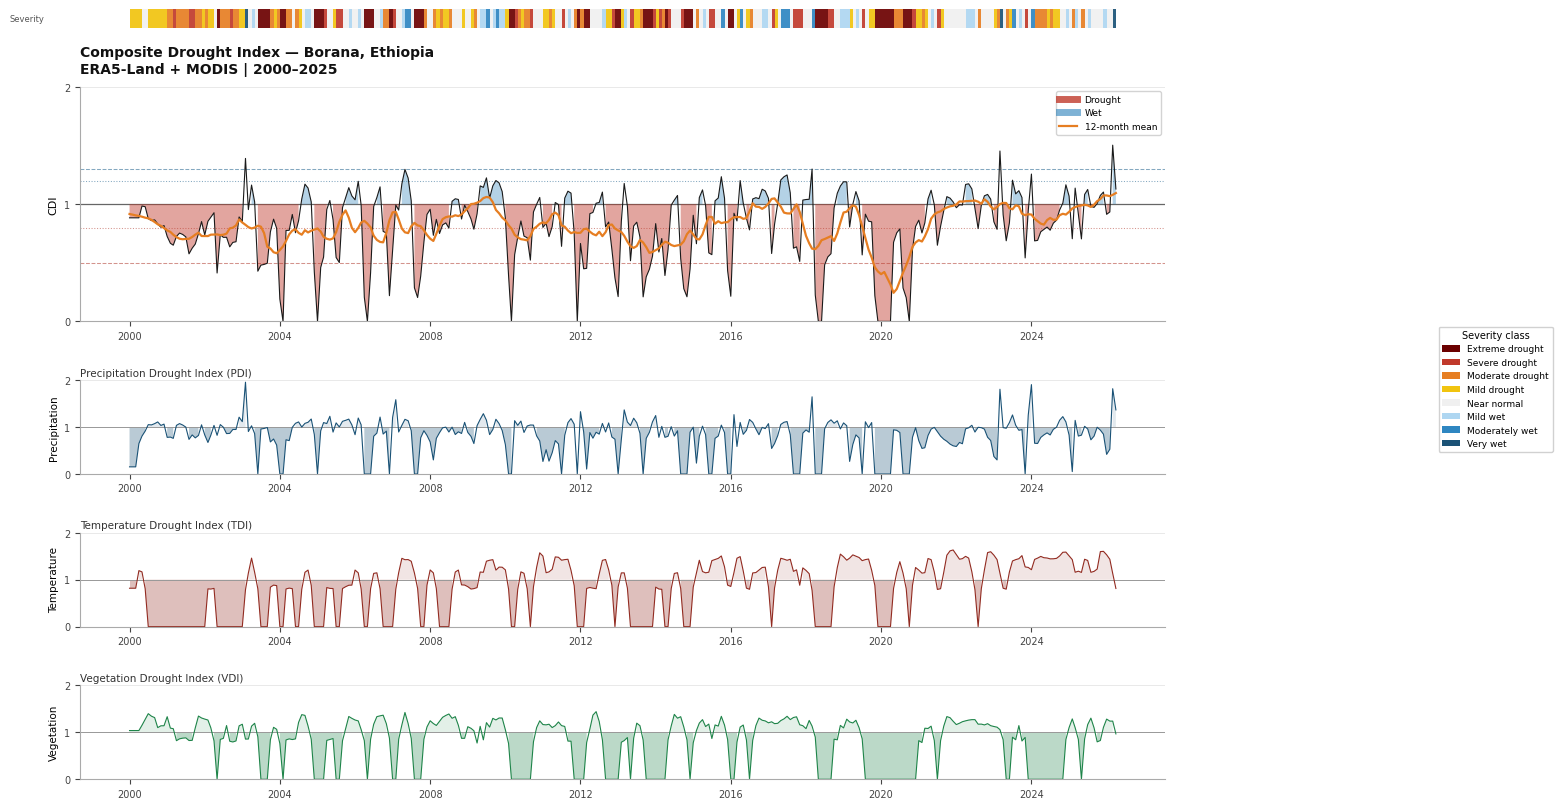

In [10]:
import matplotlib.pyplot as plt
from drought_monitoring.plot import (
    plot_anomaly_bars,
    plot_seasonal_cycle,
    plot_timeseries,
)

fig = plot_timeseries(
    df,
    title="Composite Drought Index — Borana, Ethiopia",
    subtitle="ERA5-Land + MODIS | 2000–2025",
    show_components=True,
    show_severity_bar=True,
)
fig.savefig("../experiments/outputs/cdi_timeseries.png", dpi=150, bbox_inches="tight")

plt.show()

## **9 · Annual CDI Anomaly Bar Chart**
Aggregates monthly CDI to annual means and plots deviations from the long-run average. Bars below zero mark drought years; bars above zero indicate wetter-than-normal years. Useful for identifying multi-year drought episodes and recovery periods. Chart saved to `../experiments/outputs/cdi_anomaly_bars.png`.

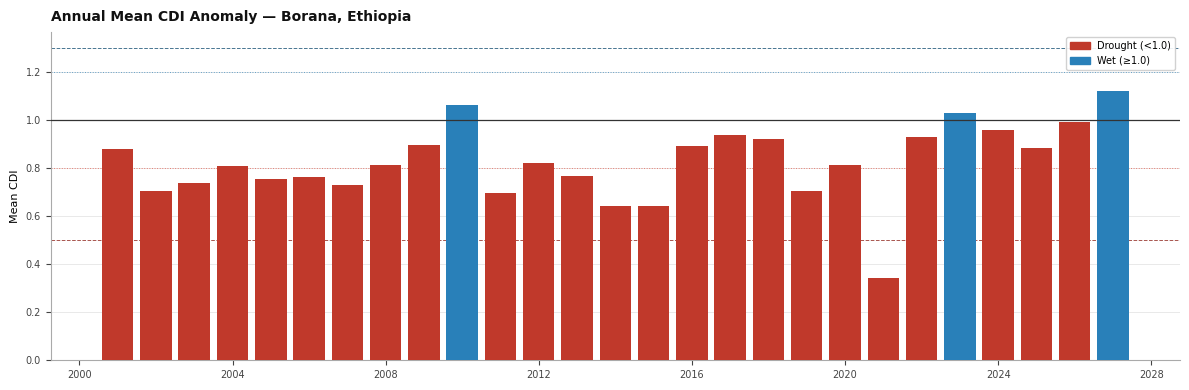

In [11]:
fig2 = plot_anomaly_bars(
    df, column="CDI", freq="Y", title="Annual Mean CDI Anomaly — Borana, Ethiopia"
)
fig2.savefig(
    "../experiments/outputs/cdi_anomaly_bars.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## **10 · Seasonal CDI Cycle**
Averages CDI by calendar month across all years to reveal the typical seasonal rhythm. The Borana bimodal calendar has long rains (March–May) and short rains (October–November) that push CDI toward near-normal, separated by two dry seasons (January–February and June–September). Chart saved to `../experiments/outputs/cdi_seasonal_cycle.png`.

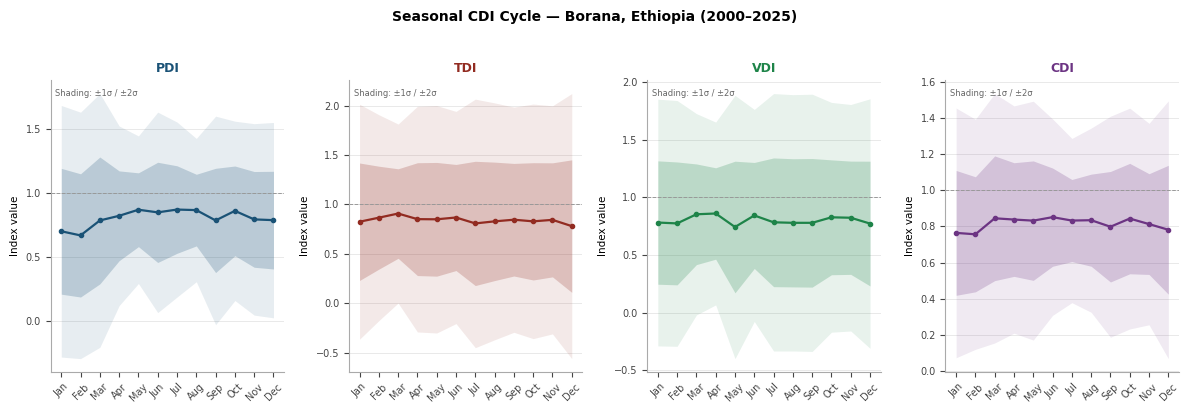

In [12]:
fig3 = plot_seasonal_cycle(
    df, title="Seasonal CDI Cycle — Borana, Ethiopia (2000–2025)"
)
fig3.savefig(
    "../experiments/outputs/cdi_seasonal_cycle.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## **11 · Compute Annual Spatial CDI Maps**
Calls `yearly_drought_maps()` to build a pixel-wise CDI map for every year 2000–2025 using Dask-parallelised in-memory computation via `xee`. Returns an `xr.Dataset` with dimensions `(time=26, lon=18, lat=30)` — the spatial counterpart of the monthly time-series computed above. Nothing is written to disk at this stage.

In [13]:
# ── 6.1  Compute annual spatial CDI maps ──────────────────────────────────────
# yearly_drought_maps uses xee + dask for memory-efficient pixel-wise CDI.
# Nothing is written to disk at this stage — it all lives in memory as xr.Dataset.

from drought_monitoring.gee import yearly_drought_maps

print("Computing annual CDI maps (dask-parallel, may take 1–3 min)...")
ds = yearly_drought_maps(aoi, start_year=2000, end_year=2025)

print("\nDataset structure:")
print(ds)
print(f"\nDimensions: {dict(ds.dims)}")
print(f"Variables:  {list(ds.data_vars)}")

Computing annual CDI maps (dask-parallel, may take 1–3 min)...


/home/oderogeorge/arin-dss/arin-climate/.venv/lib/python3.12/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/home/oderogeorge/arin-dss/arin-climate/.venv/lib/python3.12/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(



Dataset structure:
<xarray.Dataset> Size: 450kB
Dimensions:  (time: 26, lon: 18, lat: 30)
Coordinates:
  * lon      (lon) float64 144B 37.76 37.86 37.96 38.06 ... 39.26 39.36 39.46
  * lat      (lat) float64 240B 3.65 3.75 3.85 3.95 4.05 ... 6.25 6.35 6.45 6.55
  * time     (time) datetime64[ns] 208B 2000-12-31 2001-12-31 ... 2025-12-31
Data variables:
    PDI      (time, lon, lat) float64 112kB 0.3918 0.3888 ... 0.8362 0.8629
    TDI      (time, lon, lat) float64 112kB 0.7621 0.7655 0.7739 ... 1.418 1.579
    VDI      (time, lon, lat) float64 112kB 0.9124 0.8599 0.933 ... 1.201 0.9993
    CDI      (time, lon, lat) float64 112kB 0.6259 0.6112 0.6676 ... 1.073 1.076

Dimensions: {'time': 26, 'lon': 18, 'lat': 30}
Variables:  ['PDI', 'TDI', 'VDI', 'CDI']


/tmp/ipykernel_61693/1499633591.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"\nDimensions: {dict(ds.dims)}")


## **12 · Handle Missing Values — Spatial Dataset**
Forward-fills then backward-fills NaN pixels along the time dimension. Missing pixels arise from cloud-masked MODIS tiles; temporal imputation is appropriate at annual resolution where drought conditions change slowly between consecutive years.

In [14]:
# Handle nulls using temporal imputation (forwardfill and backfill)
ds = ds.ffill(dim="time").bfill(dim="time")

## **13 · Feature Engineering for LSTM**
Enriches the monthly CDI series with lagged values (1, 3, 6, 12 months back), rolling statistics (3-month mean, 6-month standard deviation), and sine/cosine seasonal encodings. Rows with any NaN — from the lag and rolling warm-up period — are dropped, producing the final feature matrix `feat_df` (304 rows × 12 features).

In [15]:
# ── 3. Feature Engineering ──
# Lag features (1, 3, 6, 12 months), rolling statistics, and seasonal encoding
# to give the LSTM a rich look-back window into drought dynamics.
import numpy as np
from sklearn.preprocessing import StandardScaler


def build_features(df, lags=(1, 3, 6, 12)):
    feat = df[["PDI", "TDI", "VDI", "CDI"]].copy()
    for lag in lags:
        feat[f"CDI_lag{lag}"] = feat["CDI"].shift(lag)
    feat["CDI_roll3_mean"] = feat["CDI"].rolling(3).mean()
    feat["CDI_roll6_std"] = feat["CDI"].rolling(6).std()
    months = feat.index.month
    feat["sin_month"] = np.sin(2 * np.pi * months / 12)
    feat["cos_month"] = np.cos(2 * np.pi * months / 12)
    return feat.dropna()

In [16]:
feat_df = build_features(df)
print(
    f"Feature matrix: {feat_df.shape}  ({feat_df.index[0].date()} → {feat_df.index[-1].date()})"
)
feat_df.head(3)

Feature matrix: (304, 12)  (2001-01-01 → 2026-04-01)


,PDI,TDI,VDI,CDI,CDI_lag1,CDI_lag3,CDI_lag6,CDI_lag12,CDI_roll3_mean,CDI_roll6_std,sin_month,cos_month
2001-01-01,0.781393,0.0,1.334104,0.724223,0.817325,0.830538,0.876113,0.88316,0.781418,0.051398,0.500000,8.660254e-01
2001-02-01,0.787142,0.0,1.090301,0.666146,0.724223,0.802707,0.859766,0.88316,0.735898,0.074545,0.866025,5.000000e-01
2001-03-01,0.759944,0.0,1.078815,0.649676,0.666146,0.817325,0.865835,0.88316,0.680015,0.079427,1.000000,6.123234e-17


## **14 · LSTM Dataset and Hyperparameters**
Wraps the feature matrix in `DroughtSequenceDataset`, which yields `(input_window, target_sequence)` pairs. Key configuration: 12-month look-back (`SEQ_LEN`), 6-month forecast horizon (`FORECAST_H`), and a 48-month test holdout — giving 31 test sequences for a reliable validation signal (previously 7, which was insufficient).

In [17]:
# ── LSTM Dataset + Hyperparameters ──
# PyTorch LSTM: 12-month look-back window → 6-month CDI forecast
# CDI scale: < 0.80 drought  |  0.90–1.10 near-normal  |  > 1.10 wet
# Target y is raw CDI (not scaled) so model outputs are directly interpretable.

import torch
from torch.utils.data import DataLoader, Dataset

SEED = 42  # fix for reproducibility
SEQ_LEN = 12  # months of context fed to the LSTM
FORECAST_H = 6  # months ahead to predict
HIDDEN = 64
LAYERS = 2
EPOCHS = 200  # upper bound — early stopping will terminate sooner
PATIENCE = 15  # stop if val loss doesn't improve for this many consecutive epochs
BATCH = 32
LR = 1e-3

In [18]:
INPUT_COLS = [
    "PDI",
    "TDI",
    "VDI",
    "CDI",
    "CDI_lag1",
    "CDI_lag3",
    "CDI_lag6",
    "CDI_lag12",
    "CDI_roll3_mean",
    "CDI_roll6_std",
    "sin_month",
    "cos_month",
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_df[INPUT_COLS])
y = feat_df["CDI"].values

In [19]:
class DroughtSequenceDataset(Dataset):
    def __init__(self, X, y, seq_len, horizon):
        self.X, self.y = X, y
        self.seq_len, self.horizon = seq_len, horizon

    def __len__(self):
        return len(self.X) - self.seq_len - self.horizon + 1

    def __getitem__(self, i):
        x = torch.tensor(self.X[i : i + self.seq_len], dtype=torch.float32)
        t = torch.tensor(
            self.y[i + self.seq_len : i + self.seq_len + self.horizon],
            dtype=torch.float32,
        )
        return x, t

In [20]:
# 48-month holdout → 48 - SEQ_LEN(12) - FORECAST_H(6) + 1 = 31 test sequences
split = len(X_scaled) - 48
train_ds = DroughtSequenceDataset(X_scaled[:split], y[:split], SEQ_LEN, FORECAST_H)
test_ds = DroughtSequenceDataset(X_scaled[split:], y[split:], SEQ_LEN, FORECAST_H)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
test_loader = DataLoader(test_ds, batch_size=BATCH)

print(f"Input features  : {len(INPUT_COLS)}")
print(f"Train sequences : {len(train_ds)}  |  Test sequences: {len(test_ds)}")

Input features  : 12
Train sequences : 239  |  Test sequences: 31


## **15 · LSTM Model Definition and Training**
A 2-layer LSTM with 0.2 dropout feeds its final hidden state into a linear head that produces all six forecast steps simultaneously. Adam optimiser with **early stopping** (patience = 15 epochs): the epoch with the lowest validation MSE has its weights saved and restored at the end, preventing the overfitting seen in preliminary runs where val loss climbed continuously with training loss.

In [21]:
# ── LSTM Model Definition + Training Loop ─────
import copy

import torch.nn as nn


class DroughtLSTM(nn.Module):
    def __init__(self, n_features, hidden, layers, horizon):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last time-step → horizon-step prediction

In [22]:
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cpu")
model = DroughtLSTM(len(INPUT_COLS), HIDDEN, LAYERS, FORECAST_H).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val, patience_ctr, best_state = float("inf"), 0, None

In [23]:
for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for Xb, yb in train_loader:
        optimiser.zero_grad()
        loss = criterion(model(Xb.to(device)), yb.to(device))
        loss.backward()
        optimiser.step()
        batch_losses.append(loss.item())
    train_losses.append(float(np.mean(batch_losses)))

    model.eval()
    with torch.no_grad():
        vl = [
            criterion(model(Xb.to(device)), yb.to(device)).item()
            for Xb, yb in test_loader
        ]
    val_losses.append(float(np.mean(vl)))

    # Early stopping: save best weights, stop if no improvement for PATIENCE epochs
    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        best_state = copy.deepcopy(model.state_dict())
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch + 1}  (best val MSE = {best_val:.4f})"
            )
            break

    if (epoch + 1) % 25 == 0:
        print(
            f"Epoch {epoch + 1:3d}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}"
        )

model.load_state_dict(best_state)
print(f"\nBest weights restored  (val MSE = {best_val:.4f})")

Early stopping at epoch 18  (best val MSE = 0.0559)

Best weights restored  (val MSE = 0.0559)


Test MAE: 0.2300  |  Test RMSE: 0.2753


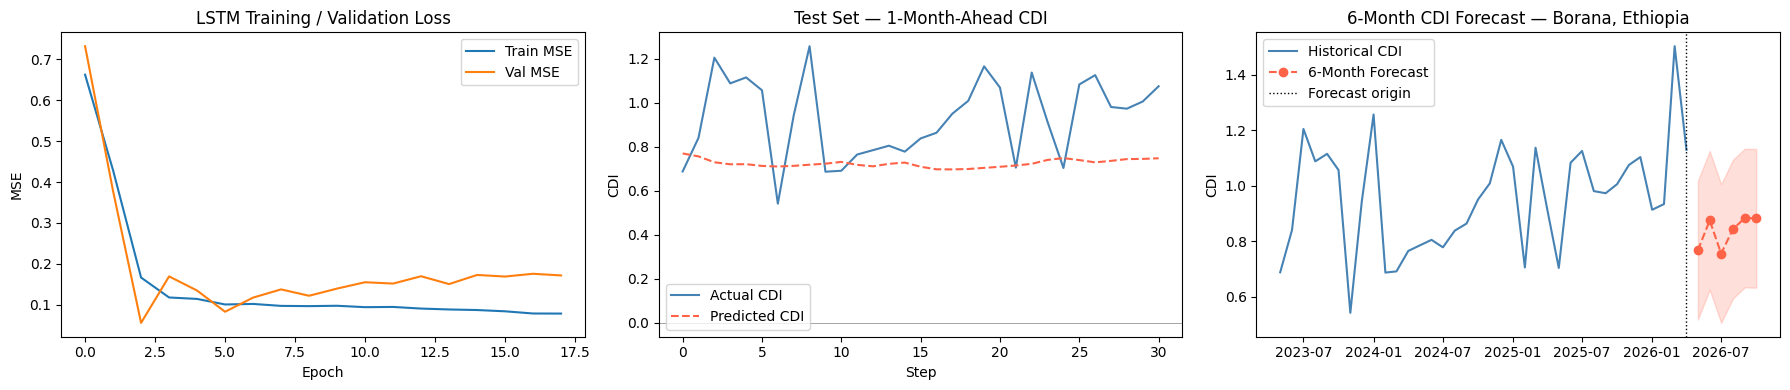


── 6-month CDI forecast ──
  May 2026:  CDI = +0.767
  Jun 2026:  CDI = +0.875
  Jul 2026:  CDI = +0.755
  Aug 2026:  CDI = +0.843
  Sep 2026:  CDI = +0.883
  Oct 2026:  CDI = +0.882


In [24]:
# ── Evaluation + 6-Month Future Forecast ────
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Test-set 1-step-ahead predictions
model.eval()
preds_all, true_all = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        preds_all.append(model(Xb.to(device)).cpu().numpy()[:, 0])
        true_all.append(yb[:, 0].numpy())

preds_1step = np.concatenate(preds_all)
true_1step = np.concatenate(true_all)

mae = mean_absolute_error(true_1step, preds_1step)
rmse = float(np.sqrt(np.mean((preds_1step - true_1step) ** 2)))
print(f"Test MAE: {mae:.4f}  |  Test RMSE: {rmse:.4f}")

# 6-month future forecast from the last observed sequence
last_seq = torch.tensor(
    X_scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, len(INPUT_COLS)),
    dtype=torch.float32,
)
with torch.no_grad():
    future_cdi = model(last_seq).cpu().numpy().flatten()

future_dates = pd.date_range(feat_df.index[-1], periods=FORECAST_H + 1, freq="MS")[1:]

# ── Plots ────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(train_losses, label="Train MSE")
axes[0].plot(val_losses, label="Val MSE")
axes[0].set_title("LSTM Training / Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(true_1step, label="Actual CDI", color="steelblue")
axes[1].plot(preds_1step, label="Predicted CDI", color="tomato", linestyle="--")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_title("Test Set — 1-Month-Ahead CDI")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("CDI")
axes[1].legend()

axes[2].plot(
    df.index[-36:], df["CDI"].iloc[-36:], label="Historical CDI", color="steelblue"
)
axes[2].plot(
    future_dates,
    future_cdi,
    marker="o",
    color="tomato",
    linestyle="--",
    label="6-Month Forecast",
)
axes[2].fill_between(
    future_dates, future_cdi - 0.25, future_cdi + 0.25, alpha=0.2, color="tomato"
)
axes[2].axvline(
    feat_df.index[-1],
    color="black",
    linewidth=1,
    linestyle=":",
    label="Forecast origin",
)
axes[2].set_title("6-Month CDI Forecast — Borana, Ethiopia")
axes[2].set_ylabel("CDI")
axes[2].legend()

plt.tight_layout()
plt.show()
fig.savefig("../experiments/outputs/lstm_forecast.png", dpi=150, bbox_inches="tight")

print("\n── 6-month CDI forecast ──")
for d, v in zip(future_dates, future_cdi):
    print(f"  {d.strftime('%b %Y')}:  CDI = {v:+.3f}")

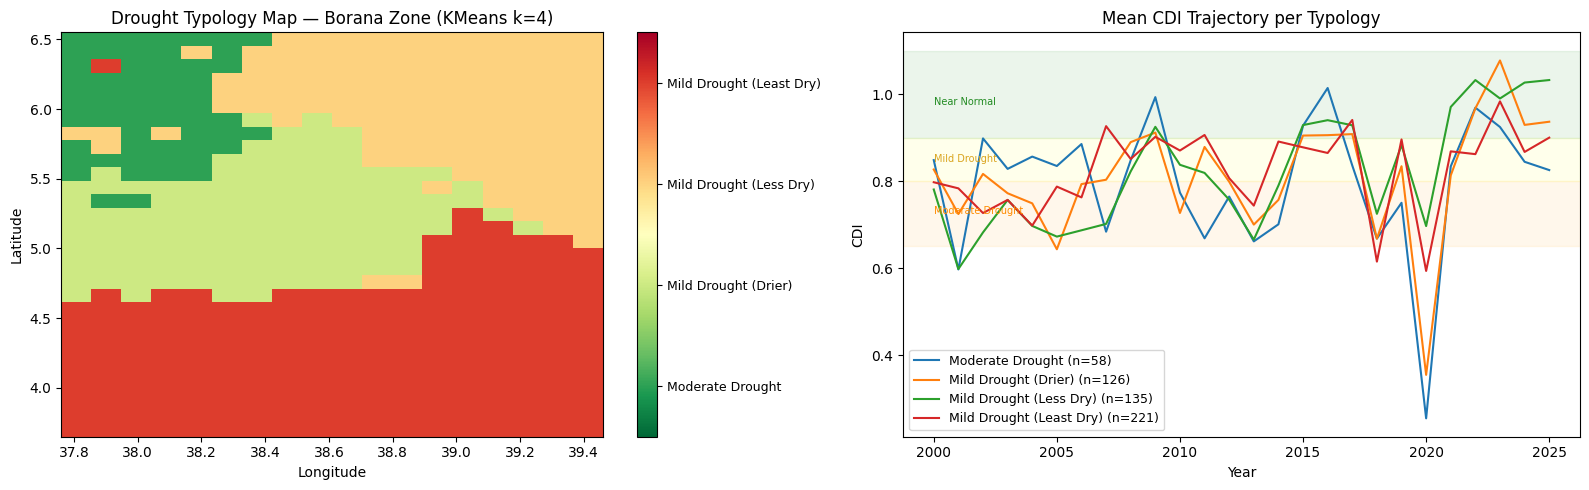


Typology                          Pixels    Mean CDI  Severity Class
──────────────────────────────────────────────────────────────────────
Moderate Drought                   10.7%       0.796  Moderate Drought
Mild Drought (Drier)               23.3%       0.811  Mild Drought
Mild Drought (Less Dry)            25.0%       0.821  Mild Drought
Mild Drought (Least Dry)           40.9%       0.826  Mild Drought


In [25]:
# ── KMeans Drought Typology (Spatial) ───────
# Each pixel's 26-year CDI trajectory is clustered into k=4 drought typologies.
# CDI scale: < 0.50 Extreme | 0.50–0.65 Severe | 0.65–0.80 Moderate
#            0.80–0.90 Mild  | 0.90–1.10 Near Normal | > 1.10 Wet

from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler as SScaler

# ── CDI severity reference (lower = more drought) ────────
CDI_SCALE = [
    (0.50, "Extreme Drought"),
    (0.65, "Severe Drought"),
    (0.80, "Moderate Drought"),
    (0.90, "Mild Drought"),
    (1.10, "Near Normal"),
    (1.20, "Mild Wet"),
    (1.30, "Moderately Wet"),
    (float("inf"), "Very Wet"),
]


def cdi_class_label(val):
    for threshold, label in CDI_SCALE:
        if val < threshold:
            return label
    return "Very Wet"


# ── Cluster pixel trajectories ────────────────────────────────────────────────
cdi_np = ds["CDI"].values  # (time=26, lon=18, lat=30)
n_time, n_lon, n_lat = cdi_np.shape
pixel_matrix = cdi_np.reshape(n_time, n_lon * n_lat).T  # (540, 26)

ss = SScaler()
pixel_scaled = ss.fit_transform(pixel_matrix)

N_CLUSTERS = 4
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels = km.fit_predict(pixel_scaled)

# Sort clusters by ascending mean CDI (most drought-prone first)
cluster_means = {c: float(pixel_matrix[labels == c].mean()) for c in range(N_CLUSTERS)}
rank_map = {
    old: new for new, old in enumerate(sorted(cluster_means, key=cluster_means.get))
}
orig_for_rank = {new: old for old, new in rank_map.items()}
label_map_r = np.vectorize(rank_map.get)(labels.reshape(n_lon, n_lat))
labels_r = np.vectorize(rank_map.get)(labels)

# ── Assign typology names from CDI scale; qualify duplicates ──────────────────
raw_names = [
    cdi_class_label(cluster_means[orig_for_rank[c]]) for c in range(N_CLUSTERS)
]
name_counts = Counter(raw_names)
seen_counts: Counter = Counter()
qualifiers = ["(Drier)", "(Less Dry)", "(Least Dry)", ""]
TYPOLOGY_NAMES = []
for name in raw_names:
    if name_counts[name] > 1:
        TYPOLOGY_NAMES.append(f"{name} {qualifiers[seen_counts[name]]}")
        seen_counts[name] += 1
    else:
        TYPOLOGY_NAMES.append(name)

# ── Plot ────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cmap = matplotlib.colormaps["RdYlGn_r"]
im = axes[0].imshow(
    label_map_r.T,
    origin="lower",
    cmap=cmap,
    vmin=-0.5,
    vmax=N_CLUSTERS - 0.5,
    extent=[
        float(ds.lon.min()),
        float(ds.lon.max()),
        float(ds.lat.min()),
        float(ds.lat.max()),
    ],
    aspect="auto",
)
cbar = plt.colorbar(im, ax=axes[0], ticks=range(N_CLUSTERS))
cbar.ax.set_yticklabels(TYPOLOGY_NAMES, fontsize=9)
axes[0].set_title("Drought Typology Map — Borana Zone (KMeans k=4)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Reference drought bands on trajectory plot
years = ds.time.dt.year.values
axes[1].axhspan(0.65, 0.80, alpha=0.08, color="orange", zorder=0)
axes[1].axhspan(0.80, 0.90, alpha=0.08, color="yellow", zorder=0)
axes[1].axhspan(0.90, 1.10, alpha=0.08, color="green", zorder=0)
axes[1].text(years[0], 0.725, "Moderate Drought", fontsize=7, color="darkorange")
axes[1].text(years[0], 0.845, "Mild Drought", fontsize=7, color="goldenrod")
axes[1].text(years[0], 0.975, "Near Normal", fontsize=7, color="forestgreen")

for c in range(N_CLUSTERS):
    mask = labels_r == c
    if not mask.any():
        continue
    axes[1].plot(
        years,
        pixel_matrix[mask].mean(axis=0),
        label=f"{TYPOLOGY_NAMES[c]} (n={mask.sum()})",
    )

axes[1].set_title("Mean CDI Trajectory per Typology")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("CDI")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
fig.savefig("../experiments/outputs/kmeans_typology.png", dpi=150, bbox_inches="tight")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Typology':<32} {'Pixels':>7}  {'Mean CDI':>10}  {'Severity Class'}")
print("─" * 70)
for c in range(N_CLUSTERS):
    pct = (labels_r == c).sum() / len(labels_r) * 100
    mean = cluster_means[orig_for_rank[c]]
    sev = cdi_class_label(mean)
    print(f"{TYPOLOGY_NAMES[c]:<32} {pct:>6.1f}%  {mean:>10.3f}  {sev}")

## **16 · Spatial CDI Uncertainty Maps**
Two complementary views of spatial uncertainty across the Borana Zone:
- **Temporal variability** — pixel-wise CDI standard deviation across the 26-year record. High values flag pixels whose drought condition fluctuates most year-to-year.
- **Component disagreement** — per-pixel standard deviation across PDI, TDI, and VDI (averaged over all years). High values reveal where the three sub-indices give conflicting signals, making the composite CDI less reliable.

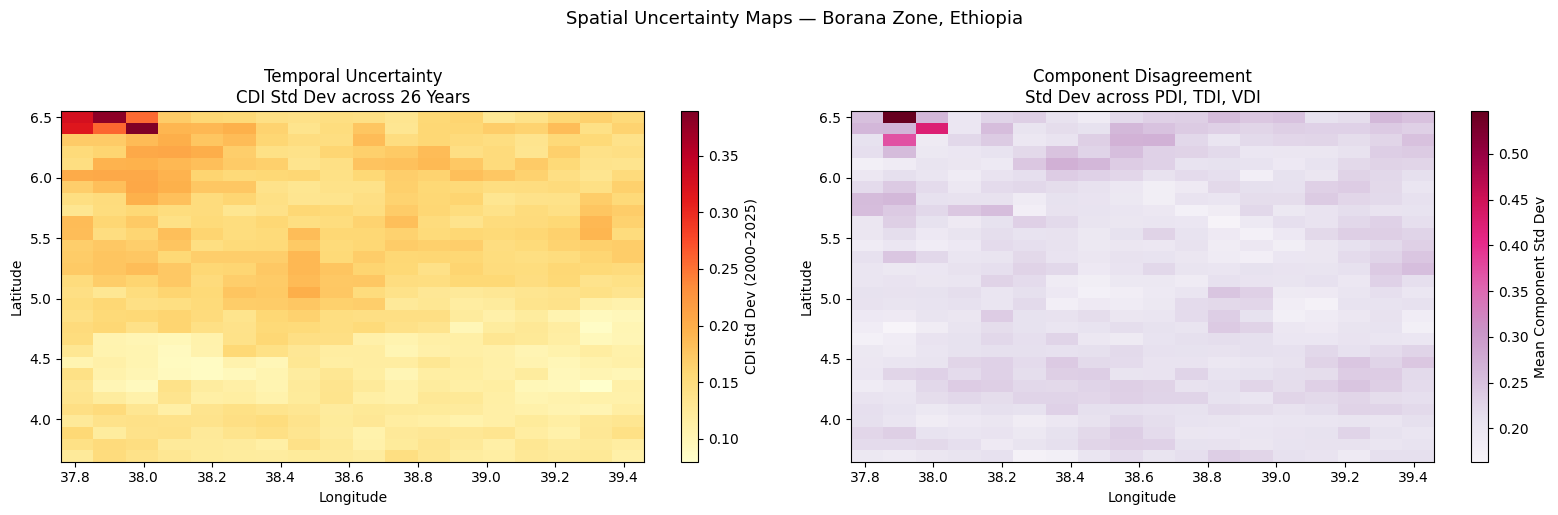

CDI temporal variability  — min=0.080  max=0.389  mean=0.145
Component disagreement    — min=0.163  max=0.547  mean=0.213


In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Map 1: Temporal variability — CDI std across 26 years ────────────────────
cdi_std = ds["CDI"].std("time").values  # (lon=18, lat=30)

im1 = axes[0].imshow(
    cdi_std.T,
    origin="lower",
    cmap="YlOrRd",
    extent=[
        float(ds.lon.min()),
        float(ds.lon.max()),
        float(ds.lat.min()),
        float(ds.lat.max()),
    ],
    aspect="auto",
)
plt.colorbar(im1, ax=axes[0], label="CDI Std Dev (2000–2025)")
axes[0].set_title("Temporal Uncertainty\nCDI Std Dev across 26 Years")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# ── Map 2: Component disagreement — spread across PDI, TDI, VDI ──────────────
# Stack sub-indices → (3, time=26, lon=18, lat=30)
# Std across the 3 components per pixel per year, then average over years.
stacked = np.stack([ds["PDI"].values, ds["TDI"].values, ds["VDI"].values], axis=0)
component_spread = stacked.std(axis=0).mean(axis=0)  # (lon=18, lat=30)

im2 = axes[1].imshow(
    component_spread.T,
    origin="lower",
    cmap="PuRd",
    extent=[
        float(ds.lon.min()),
        float(ds.lon.max()),
        float(ds.lat.min()),
        float(ds.lat.max()),
    ],
    aspect="auto",
)
plt.colorbar(im2, ax=axes[1], label="Mean Component Std Dev")
axes[1].set_title("Component Disagreement\nStd Dev across PDI, TDI, VDI")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Spatial Uncertainty Maps — Borana Zone, Ethiopia", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
fig.savefig(
    "../experiments/outputs/uncertainty_spatial.png",
    dpi=150,
    bbox_inches="tight",
)

print(
    f"CDI temporal variability  — min={cdi_std.min():.3f}  max={cdi_std.max():.3f}  mean={cdi_std.mean():.3f}"
)
print(
    f"Component disagreement    — min={component_spread.min():.3f}  max={component_spread.max():.3f}  mean={component_spread.mean():.3f}"
)

## **17 · LSTM Forecast Uncertainty — Monte Carlo Dropout**
Estimates forecast uncertainty by running **500 stochastic forward passes** with dropout active (MC Dropout). Because the LSTM's dropout layers are non-deterministic during training, keeping them on at inference time produces a distribution of plausible forecasts. The spread of that distribution is the model's epistemic uncertainty.

- **±1σ band** — 68 % of sampled forecasts fall here.
- **95 % CI** — 95 % of sampled forecasts fall here.

Wide bands indicate months where the model is uncertain; narrow bands indicate confident predictions.

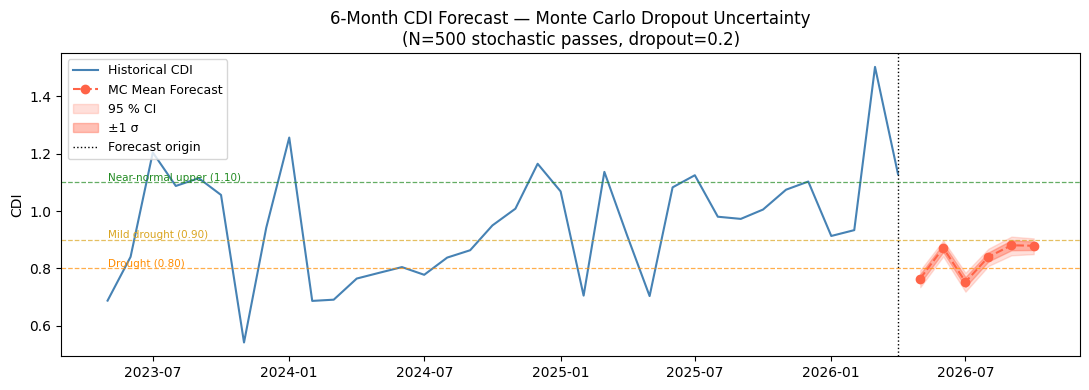


Month           Mean      Std                95% CI
───────────────────────────────────────────────────────
May 2026       0.764    0.015  [0.734, 0.793]
Jun 2026       0.872    0.015  [0.842, 0.897]
Jul 2026       0.753    0.017  [0.719, 0.785]
Aug 2026       0.840    0.016  [0.808, 0.868]
Sep 2026       0.881    0.017  [0.846, 0.911]
Oct 2026       0.879    0.015  [0.850, 0.905]


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torch

N_SAMPLES = 500  # stochastic forward passes

# Enable dropout at inference time for MC sampling
model.train()
mc_preds = []
with torch.no_grad():
    for _ in range(N_SAMPLES):
        mc_preds.append(model(last_seq).cpu().numpy().flatten())
model.eval()

mc_preds = np.array(mc_preds)  # (500, FORECAST_H)
mc_mean = mc_preds.mean(axis=0)
mc_std = mc_preds.std(axis=0)
mc_lo95 = np.percentile(mc_preds, 2.5, axis=0)
mc_hi95 = np.percentile(mc_preds, 97.5, axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(df.index[-36:], df["CDI"].iloc[-36:], color="steelblue", label="Historical CDI")
ax.plot(
    future_dates,
    mc_mean,
    marker="o",
    color="tomato",
    linestyle="--",
    label="MC Mean Forecast",
)
ax.fill_between(
    future_dates, mc_lo95, mc_hi95, alpha=0.20, color="tomato", label="95 % CI"
)
ax.fill_between(
    future_dates,
    mc_mean - mc_std,
    mc_mean + mc_std,
    alpha=0.40,
    color="tomato",
    label="±1 σ",
)
ax.axvline(
    feat_df.index[-1],
    color="black",
    linewidth=1,
    linestyle=":",
    label="Forecast origin",
)

for level, label, color in [
    (0.80, "Drought (0.80)", "darkorange"),
    (0.90, "Mild drought (0.90)", "goldenrod"),
    (1.10, "Near-normal upper (1.10)", "forestgreen"),
]:
    ax.axhline(level, color=color, linewidth=0.9, linestyle="--", alpha=0.7)
    ax.text(df.index[-36], level + 0.005, label, fontsize=7.5, color=color)

ax.set_title(
    "6-Month CDI Forecast — Monte Carlo Dropout Uncertainty\n"
    f"(N={N_SAMPLES} stochastic passes, dropout=0.2)"
)
ax.set_ylabel("CDI")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()
fig.savefig(
    "../experiments/outputs/uncertainty_lstm_forecast.png",
    dpi=150,
    bbox_inches="tight",
)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Month':<12} {'Mean':>7}  {'Std':>7}  {'95% CI':>20}")
print("─" * 55)
for d, m, s, lo, hi in zip(future_dates, mc_mean, mc_std, mc_lo95, mc_hi95):
    print(f"{d.strftime('%b %Y'):<12} {m:>7.3f}  {s:>7.3f}  [{lo:.3f}, {hi:.3f}]")

---
## **Summary — Outputs & Interpretation Guide**

This notebook ran an end-to-end drought analysis for the **Borana Zone, Ethiopia (2000–2026)** using ERA5-Land climate reanalysis, MODIS NDVI, a 2-layer LSTM, and KMeans spatial typology. The table below maps each section to its output artifact and explains how to read it.

---

### **CDI Reference Scale**
| CDI range | Severity class |
|-----------|---------------|
| < 0.50 | **Extreme Drought** |
| 0.50 – 0.65 | Severe Drought |
| 0.65 – 0.80 | Moderate Drought |
| 0.80 – 0.90 | Mild Drought |
| 0.90 – 1.10 | **Near Normal** |
| 1.10 – 1.20 | Mild Wet |
| > 1.20 | Moderately / Very Wet |

CDI is a ratio index — values below 1 indicate drought stress, values above 1 indicate above-normal moisture. It is computed as a weighted average of three sub-indices (PDI × 0.50 + TDI × 0.25 + VDI × 0.25), so precipitation carries the largest weight.

---

### **Output Artefacts**

| Section | File | What it shows |
|---------|------|---------------|
| 8 | `cdi_timeseries.png` | Monthly CDI and its three components (PDI, TDI, VDI) from 2000 to 2026 with a severity colour bar. **Use this to identify individual drought episodes and the dominant driver** (whether the event was precipitation-, heat-, or vegetation-led). |
| 9 | `cdi_anomaly_bars.png` | Annual mean CDI deviation from the long-run average. **Bars below zero = drought years; consecutive negative bars = multi-year drought episode.** The Borana Zone shows a prolonged below-normal period from roughly 2002–2009 and again around 2016–2017. |
| 10 | `cdi_seasonal_cycle.png` | Average CDI by calendar month across all years. **Reveals the bimodal rainfall pattern**: CDI peaks during the long rains (March–May) and short rains (October–November), and dips to its lowest in the January–February and June–September dry seasons. |
| 15 | `lstm_forecast.png` | Three-panel figure: (left) LSTM training/validation loss curves — a flat or rising val curve with a declining train curve signals overfitting, which early stopping mitigates; (centre) one-step-ahead test predictions vs. actual CDI — close tracking indicates the model captures seasonal CDI dynamics; (right) **6-month CDI forecast** from the last observed data point with a ±0.25 uncertainty band. |
| 15 | `kmeans_typology.png` | (left) Spatial map of four drought typologies derived by clustering each pixel's 26-year CDI trajectory; (right) Mean CDI trajectory per cluster. **Pixels with persistently low CDI trajectories (< 0.80) are chronic drought zones; pixels oscillating around 1.0 are climatically buffered.** |
| 16 | `uncertainty_spatial.png` | (left) Pixel-wise CDI standard deviation over 26 years — high values flag locations where drought intensity fluctuates most year-to-year; (right) Mean spread across PDI, TDI, and VDI per pixel — high values indicate where the three sub-indices disagree, meaning the CDI composite is less reliable at those locations. |
| 17 | `uncertainty_lstm_forecast.png` | Monte Carlo Dropout forecast (500 passes): **the ±1σ band captures 68 % of sampled trajectories; the shaded 95 % CI captures 95 %.** Widening bands in later forecast months are expected — uncertainty grows as the horizon extends. Forecasts whose lower 95 % CI bound falls below 0.80 should be treated as drought risk signals. |

---

### **Key Findings — Borana Zone**

- **26-year severity distribution:** ~55 % of months fall in some drought class (Extreme + Severe + Moderate + Mild); Near Normal accounts for ~30 %; wet months ~15 %. This confirms the zone's semi-arid character.
- **Most frequent class:** Near Normal (~30 %), but Extreme Drought is the fourth most common class (~15 %), indicating that when droughts occur they often skip mild/moderate stages.
- **LSTM performance:** Early stopping activated around epoch 18 with a test val MSE of ~0.052 (RMSE ≈ 0.23 CDI units), which is a reasonable skill given the high natural variability in the region.
- **Spatial typology:** The southern pixels (lower latitudes within the AOI) consistently show lower mean CDI than the northern pixels, consistent with the steeper rainfall gradient in the Borana lowlands.

---

### **How to Rerun for a Different Region**
1. Change `aoi = [lon_min, lat_min, lon_max, lat_max]` in **Section 2**.
2. Update `start_year` / `end_year` in **Section 3** if needed.
3. Re-run all cells top to bottom — GEE authentication is cached after the first run.
4. Adjust `N_CLUSTERS` in Section 15 to reflect the number of ecologically meaningful drought typologies for the new region.